## Run initially to download data otherwise ignore


In [ ]:
pip install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tunguz/superconductivty-data-data-set")

print("Path to dataset files:", path)

## Main code

In [1]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn import metrics
from sklearn.linear_model import ElasticNet, ElasticNetCV
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures


# maximize display of dataframe columns
pd.set_option('display.max_columns', None)

# maximize display of dataframe rows
pd.set_option('display.max_rows', None)

First I am simply opening the data file and examining its contents

In [2]:
file = './train.csv' # path to the data file

with open(file, 'r') as f:
    reader = csv.reader(f)
    labels = next(reader)
    data = [row for row in reader]

# Convert data to DataFrame for easier handling
df = pd.DataFrame(data, columns=labels)

In [3]:
df.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,wtd_std_atomic_mass,mean_fie,wtd_mean_fie,gmean_fie,wtd_gmean_fie,entropy_fie,wtd_entropy_fie,range_fie,wtd_range_fie,std_fie,wtd_std_fie,mean_atomic_radius,wtd_mean_atomic_radius,gmean_atomic_radius,wtd_gmean_atomic_radius,entropy_atomic_radius,wtd_entropy_atomic_radius,range_atomic_radius,wtd_range_atomic_radius,std_atomic_radius,wtd_std_atomic_radius,mean_Density,wtd_mean_Density,gmean_Density,wtd_gmean_Density,entropy_Density,wtd_entropy_Density,range_Density,wtd_range_Density,std_Density,wtd_std_Density,mean_ElectronAffinity,wtd_mean_ElectronAffinity,gmean_ElectronAffinity,wtd_gmean_ElectronAffinity,entropy_ElectronAffinity,wtd_entropy_ElectronAffinity,range_ElectronAffinity,wtd_range_ElectronAffinity,std_ElectronAffinity,wtd_std_ElectronAffinity,mean_FusionHeat,wtd_mean_FusionHeat,gmean_FusionHeat,wtd_gmean_FusionHeat,entropy_FusionHeat,wtd_entropy_FusionHeat,range_FusionHeat,wtd_range_FusionHeat,std_FusionHeat,wtd_std_FusionHeat,mean_ThermalConductivity,wtd_mean_ThermalConductivity,gmean_ThermalConductivity,wtd_gmean_ThermalConductivity,entropy_ThermalConductivity,wtd_entropy_ThermalConductivity,range_ThermalConductivity,wtd_range_ThermalConductivity,std_ThermalConductivity,wtd_std_ThermalConductivity,mean_Valence,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.9444675,57.8626922857143,66.3615924315719,36.1166119053847,1.1817952393305,1.06239554519617,122.90607,31.7949208571429,51.9688277861034,53.6225345301219,775.425,1010.26857142857,718.15289995213,938.016780052204,1.30596703599158,0.791487788469155,810.6,735.985714285714,323.811807806633,355.562966713294,160.25,105.514285714286,136.126003095455,84.528422716633,1.25924397214289,1.20703998701461,205,42.9142857142857,75.2375404967494,69.2355694829807,4654.35725,2961.50228571429,724.953210852388,53.5438109235142,1.03312880053102,0.814598190091683,8958.571,1579.58342857143,3306.1628967555,3572.59662370838,81.8375,111.727142857143,60.1231785550982,99.4146820543113,1.15968659338134,0.787381690763223,127.05,80.9871428571429,51.4337118896741,42.55839575195,6.9055,3.84685714285714,3.47947484936327,1.04098598567486,1.08857534188499,0.994998193254128,12.878,1.74457142857143,4.59906411675245,4.66691955388659,107.756645,61.0151885714286,7.06248773046785,0.62197948704754,0.308147989812345,0.262848266362233,399.97342,57.1276685714286,168.854243757651,138.51716251123,2.25,2.25714285714286,2.21336383940064,2.21978342968743,1.36892236074022,1.0662210317362,1,1.08571428571429,0.433012701892219,0.43705881545081,29
1,5,92.729214,58.5184161428571,73.1327872225065,36.3966020291995,1.44930919335685,1.05775512271911,122.90607,36.161939,47.0946331703134,53.9798696513451,766.44,1010.61285714286,720.605510513725,938.745412527433,1.54414454326973,0.807078214938731,810.6,743.164285714286,290.183029138508,354.963511171592,161.2,104.971428571429,141.465214777999,84.3701669575628,1.50832754035259,1.2041147982326,205,50.5714285714286,67.321319060161,68.0088169554027,5821.4858,3021.01657142857,1237.09508033858,54.0957182556368,1.31444218462105,0.914802177066343,10488.571,1667.38342857143,3767.40317577062,3632.64918471043,90.89,112.316428571429,69.8333146094209,101.166397739874,1.42799655342352,0.83866646563365,127.05,81.2078571428572,49.4381674417651,41.6676207979191,7.7844,3.79685714285714,4.40379049753476,1.03525111582814,1.37497728009085,1.07309384625263,12.878,1.59571428571429,4.47336265464807,4.60300005985449,172.205316,61.3723314285714,16.0642278788044,0.619734632330547,0.847404163195705,0.567706107876637,429.97342,51.4133828571429,198.554600255545,139.630922368904,2,2.25714285714286,1.8881750225898,2.21067940870655,1.55711309805765,1.04722136819323,2,1.12857142857143,0.632455532033676

Here I filter the target values (temperature) out of the data creating two arrays, one for the features, and one for the targets

In [4]:
target = 'critical_temp'
features = [col for col in df.columns if col != target]

X = df[features].astype(float) # Features
y = df[target].astype(float) # Targets

Next, I split the data into training and testing groups with an 80/20 ratio, and scale the data.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Split data into training and testing sets

scaler = StandardScaler() # Standardize features by removing the mean and scaling to unit variance

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
X_train.shape  # there are 81 initial features

(17010, 81)

With this initial data of 81 featues, I will perform a hyperparameter grid search to find the most optimal initial settings.

In [7]:
# grid search for hyperparameter tuning

param_grid = {'alpha': [0.1, 1, 5, 10, 50, 100], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]}

elastic_net = ElasticNet(max_iter=10000, random_state=42)

grid_search = GridSearchCV(estimator=elastic_net, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
best_alpha = grid_search.best_params_['alpha']
best_l1_ratio = grid_search.best_params_['l1_ratio']
print(f"Best alpha: {best_alpha}")
print(f"Best l1_ratio: {best_l1_ratio}")

Best alpha: 0.1
Best l1_ratio: 1.0


In [8]:
# Look at grid search results
results = pd.DataFrame(grid_search.cv_results_)
results = results.sort_values(by='mean_test_score', ascending=False)
print(results[['param_alpha', 'param_l1_ratio', 'mean_test_score']])

    param_alpha  param_l1_ratio  mean_test_score
7           0.1            1.00         0.708856
6           0.1            0.99         0.708189
5           0.1            0.95         0.705719
4           0.1            0.90         0.703460
3           0.1            0.70         0.697503
2           0.1            0.50         0.693772
1           0.1            0.30         0.690471
0           0.1            0.10         0.687422
15          1.0            1.00         0.648821
14          1.0            0.99         0.647154
13          1.0            0.95         0.642817
12          1.0            0.90         0.638418
11          1.0            0.70         0.626951
10          1.0            0.50         0.621912
9           1.0            0.30         0.618940
8           1.0            0.10         0.616923
23          5.0            1.00         0.548214
22          5.0            0.99         0.545093
16          5.0            0.10         0.542028
21          5.0     

Once the best hyperparameters are found, train the Elestic Net model

In [9]:
#  Train the model with the best hyperparameters
model = ElasticNet()

model.set_params(alpha=best_alpha, l1_ratio=best_l1_ratio)
model.fit(X_train_scaled, y_train)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(model, X_train_scaled, y_train, cv=cv, scoring='r2', return_train_score=True)

train_scores = cv_results['train_score']
test_scores = cv_results['test_score']

train_uncertainty = np.std(train_scores)
test_uncertainty = np.std(test_scores)

print(f"Mean Train R^2: {np.mean(train_scores):.4f} ± {train_uncertainty:.4f}")
print(f"Mean Test R^2: {np.mean(test_scores):.4f} ± {test_uncertainty:.4f}")

Mean Train R^2: 0.7107 ± 0.0020
Mean Test R^2: 0.7090 ± 0.0089


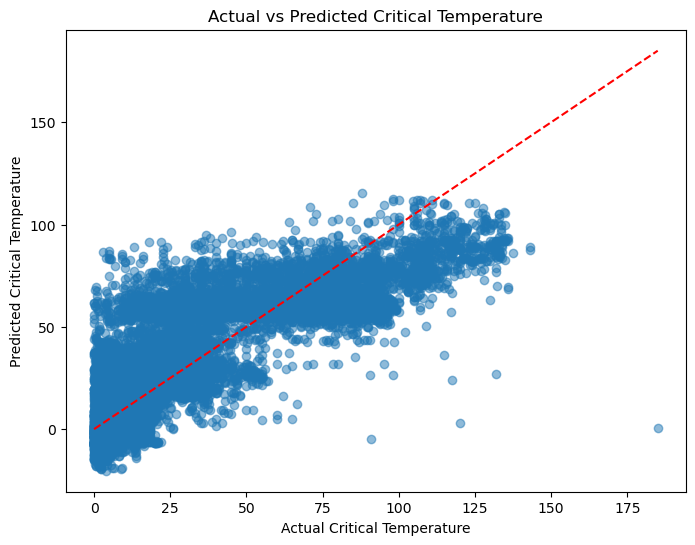

In [10]:
ypred = cross_val_predict(model, X_train_scaled, y_train, cv=cv)

# Plot actual vs predicted critical temperatures
plt.figure(figsize=(8, 6))
plt.scatter(y_train, ypred, alpha=0.5) 
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Line for perfect predictions
plt.xlabel('Actual Critical Temperature')
plt.ylabel('Predicted Critical Temperature')
plt.title('Actual vs Predicted Critical Temperature')
plt.show()

The initial results give the following results:

Mean Train $R^2$: $0.7107 \pm 0.0020$

Mean Test $R^2$: $0.7090 \pm 0.0089$

This shows some intrinsic correlation, but not a strong one. Let's see if we can make it better by finding top 15 most important features and engineering new features out of these.

In [11]:
# Get absolute coefficient magnitudes
important = pd.Series(model.coef_, index=X.columns)

# Sort by absolute value (descending order)
important_sorted = important.abs().sort_values(ascending=False)

print("Number of selected features:", len(important))

for i in range(len(important_sorted)):
    print(f"{i + 1}  {important_sorted.index[i]}: {important_sorted[i]}")

Number of selected features: 81
1  wtd_mean_ThermalConductivity: 16.99936944922887
2  wtd_gmean_ThermalConductivity: 13.115463146731626
3  std_ElectronAffinity: 11.537521944233896
4  range_atomic_radius: 10.755853008686994
5  range_atomic_mass: 9.543337834387131
6  range_ElectronAffinity: 9.312567385680522
7  wtd_entropy_ElectronAffinity: 7.4998613040300315
8  wtd_std_Valence: 6.454237211876943
9  wtd_entropy_atomic_mass: 6.441522049345838
10  wtd_entropy_FusionHeat: 6.136012105846035
11  wtd_entropy_Density: 5.167031093234067
12  wtd_mean_atomic_radius: 4.745173260406755
13  wtd_gmean_ElectronAffinity: 4.730085208619436
14  wtd_std_atomic_mass: 4.294940290276985
15  std_atomic_radius: 3.9858385881885625
16  wtd_entropy_ThermalConductivity: 3.6415253508100918
17  wtd_range_ElectronAffinity: 3.5647435040240953
18  wtd_std_ElectronAffinity: 3.54630901952223
19  wtd_entropy_atomic_radius: 3.455061678197464
20  wtd_range_Valence: 3.131047920474071
21  wtd_range_atomic_radius: 3.00099424194

C:\Users\Ben\AppData\Local\Temp\ipykernel_24512\3678223263.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"{i + 1}  {important_sorted.index[i]}: {important_sorted[i]}")


In [12]:
cropped_idx = important.index[important.abs() != 0.0].tolist()
print("Number of features after cropping:", len(cropped_idx))

# Create a new DataFrame with only the selected features
cropped_featues = X[cropped_idx] 
cropped_names = cropped_featues.columns.tolist()

X_cropped = pd.DataFrame(cropped_featues, columns=cropped_names)

Number of features after cropping: 44


In [13]:
# Create polynomial features for the top 15 most important features
top_features = important_sorted.head(15).index
X_top = X[top_features]

poly = PolynomialFeatures(2, include_bias=False)

X_poly = poly.fit_transform(X_top)
poly_feature_names  = poly.get_feature_names_out(top_features)

# Create a new DataFrame with the polynomial features
X_engineered = pd.DataFrame(X_poly, columns=poly_feature_names)

# Combine the cropped features with the polynomial features
new_features = pd.concat([X_cropped, X_engineered], axis=1)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(new_features, y, test_size=0.2, random_state=42) # Split data into training and testing sets

scaler = StandardScaler() # Standardize features by removing the mean and scaling to unit variance

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
X_train.shape # there are 179 features after feature engineering, 44 of the original features, and 135 polynomial features

(17010, 179)

After engineering new features, there are a total of 179 features. Of these features, 44 of them are from the original dataset. All of the other original features were turned off by Elastic Net. Let's grid search again and train a new model with this new set of features.

In [16]:
# grid search for hyperparameter tuning

param_grid = {'alpha': [0.1, 1, 5, 10, 50, 100], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]}

elastic_net = ElasticNet(max_iter=10000, random_state=42) # maybe set higher max_iter to ensure convergence

grid_search = GridSearchCV(estimator=elastic_net, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
best_alpha = grid_search.best_params_['alpha']
best_l1_ratio = grid_search.best_params_['l1_ratio']
print(f"Best alpha: {best_alpha}")
print(f"Best l1_ratio: {best_l1_ratio}")

Best alpha: 0.1
Best l1_ratio: 1.0


In [17]:
# Look at grid search results
results = pd.DataFrame(grid_search.cv_results_)
results = results.sort_values(by='mean_test_score', ascending=False)
print(results[['param_alpha', 'param_l1_ratio', 'mean_test_score']])

    param_alpha  param_l1_ratio  mean_test_score
7           0.1            1.00         0.766472
6           0.1            0.99         0.765849
5           0.1            0.95         0.764203
4           0.1            0.90         0.762926
3           0.1            0.70         0.759835
2           0.1            0.50         0.757765
1           0.1            0.30         0.756135
0           0.1            0.10         0.754751
15          1.0            1.00         0.704051
14          1.0            0.99         0.703255
13          1.0            0.95         0.702044
12          1.0            0.90         0.701446
8           1.0            0.10         0.701220
11          1.0            0.70         0.699962
9           1.0            0.30         0.699557
10          1.0            0.50         0.699059
16          5.0            0.10         0.644047
17          5.0            0.30         0.630703
18          5.0            0.50         0.616486
23          5.0     

In [18]:
#  Train the model with the best hyperparameters
model = ElasticNet(max_iter=10000)

model.set_params(alpha=best_alpha, l1_ratio=best_l1_ratio)
model.fit(X_train_scaled, y_train)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(model, X_train_scaled, y_train, cv=cv, scoring='r2', return_train_score=True)

train_scores = cv_results['train_score']
test_scores = cv_results['test_score']

train_uncertainty = np.std(train_scores)
test_uncertainty = np.std(test_scores)

print(f"Mean Train R^2: {np.mean(train_scores):.4f} ± {train_uncertainty:.4f}")
print(f"Mean Test R^2: {np.mean(test_scores):.4f} ± {test_uncertainty:.4f}")

Mean Train R^2: 0.7685 ± 0.0016
Mean Test R^2: 0.7667 ± 0.0053


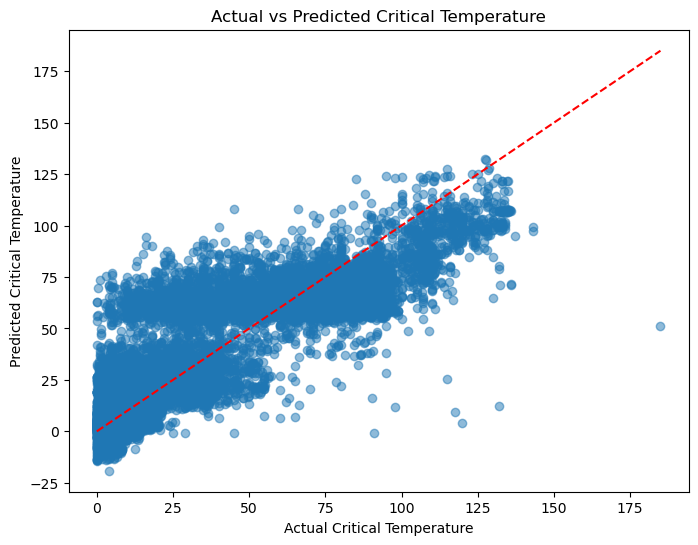

In [19]:
ypred = cross_val_predict(model, X_train_scaled, y_train, cv=cv)

plt.figure(figsize=(8, 6))
plt.scatter(y_train, ypred, alpha=0.5) 
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Line for perfect predictions
plt.xlabel('Actual Critical Temperature')
plt.ylabel('Predicted Critical Temperature')
plt.title('Actual vs Predicted Critical Temperature')
plt.show()

By making these changes, the new score is:

Mean Train $R^2$: $0.7685 \pm 0.0016$

Mean Test $R^2$: $0.7667 \pm 0.0053$

This is an improvment to the original which mean I am headed in the right direction.

In [20]:
# Get absolute coefficient magnitudes
important = pd.Series(model.coef_, index=new_features.columns)

# Sort by absolute value (descending order)
important_sorted = important.abs().sort_values(ascending=False)

print("Number of selected features:", len(important))

for i in range(len(important_sorted)):
    print(f"{i + 1}  {important_sorted.index[i]}: {important_sorted[i]}")

Number of selected features: 179
1  wtd_mean_ThermalConductivity range_atomic_radius: 14.244544181788473
2  wtd_std_Valence std_atomic_radius: 9.62518754187789
3  wtd_mean_ThermalConductivity wtd_entropy_ElectronAffinity: 8.856687300641415
4  wtd_mean_ThermalConductivity wtd_std_atomic_mass: 7.694882945018952
5  wtd_mean_ThermalConductivity range_atomic_mass: 6.700204752484174
6  wtd_std_Valence^2: 6.062402165842369
7  std_ElectronAffinity range_atomic_radius: 5.723741037957131
8  wtd_gmean_ThermalConductivity range_atomic_radius: 5.66669121622963
9  wtd_gmean_ThermalConductivity range_atomic_mass: 5.464148961305102
10  wtd_entropy_ThermalConductivity: 5.447984303074289
11  range_atomic_mass wtd_entropy_FusionHeat: 5.415549963596401
12  wtd_entropy_Density^2: 5.152509674597835
13  std_ElectronAffinity wtd_entropy_FusionHeat: 5.119297217322822
14  range_ElectronAffinity: 4.893998988393375
15  range_atomic_radius range_atomic_mass: 4.87383025396141
16  wtd_mean_ThermalConductivity wtd_en

C:\Users\Ben\AppData\Local\Temp\ipykernel_24512\1292869222.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"{i + 1}  {important_sorted.index[i]}: {important_sorted[i]}")


In [21]:
new_cropped_idx = important.index[important.abs() != 0.0].tolist()
print("Number of features after cropping:", len(new_cropped_idx))

Number of features after cropping: 72


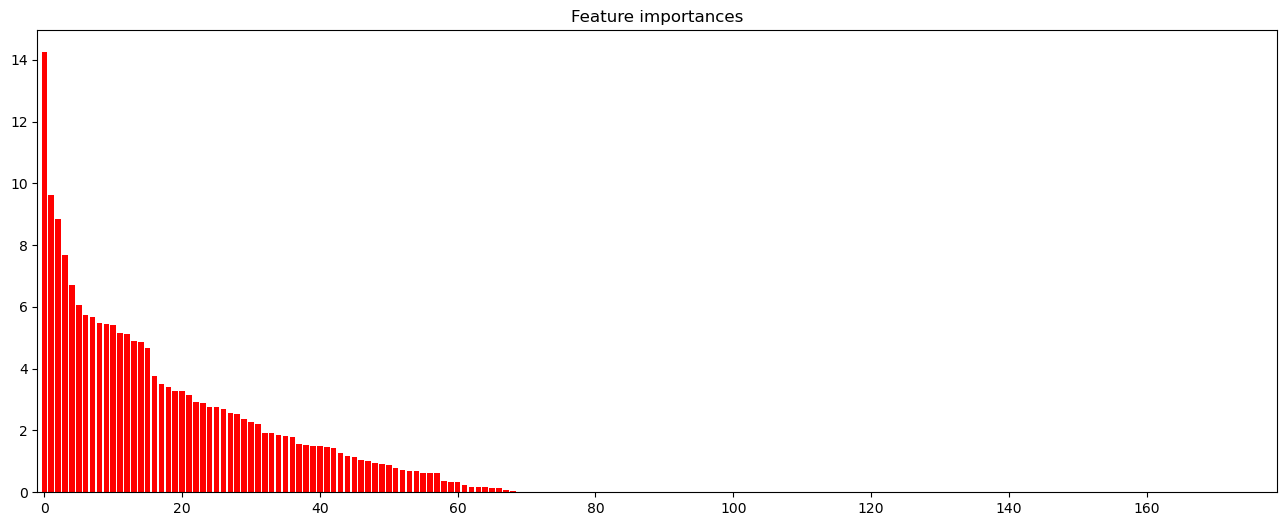

In [22]:
# Plot the feature importances 
plt.figure(figsize=(16,6))
plt.title("Feature importances")
plt.bar(range(new_features.shape[1]), important_sorted, color="r", align="center")
plt.xlim([-1, new_features.shape[1]])
plt.show()

As you can see above, of the 179 featues, only 72 survived. These are the top features (some original and some engineered) that are important for our model. This is great, however 74 is still a lot of features, let's visualize how important each of these are by looking at the cumylative feature importance.

C:\Users\Ben\AppData\Local\Temp\ipykernel_24512\3913946992.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total = cumulative[-1]


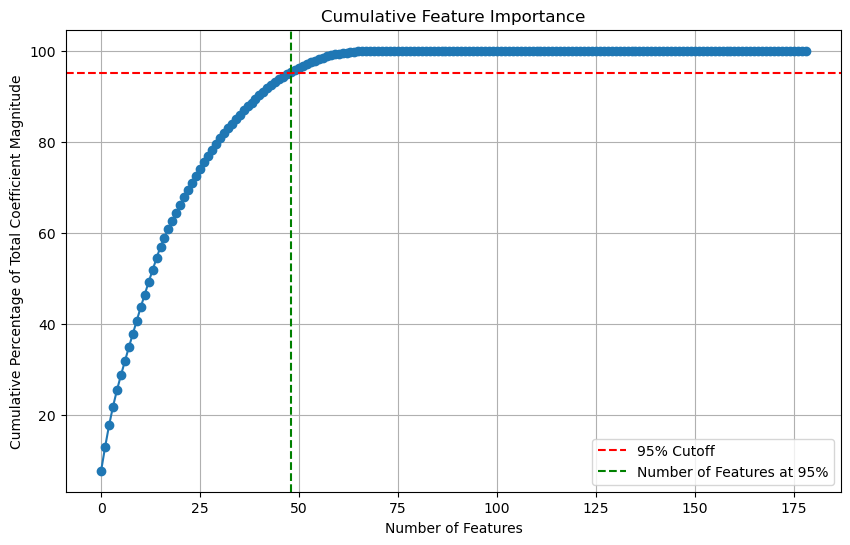

In [23]:
cumulative = np.cumsum(important_sorted)
total = cumulative[-1]
cumulative_percentage = cumulative / total * 100  # percent of total

plt.figure(figsize=(10, 6))
plt.plot(range(len(cumulative_percentage)), cumulative_percentage, marker='o')
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Percentage of Total Coefficient Magnitude')
plt.title('Cumulative Feature Importance')
plt.axhline(y=95, color='r', linestyle='--', label='95% Cutoff')
plt.axvline(x=np.where(cumulative_percentage >= 95)[0][0], color='g', linestyle='--', label='Number of Features at 95%')
plt.legend()
plt.grid()

In [24]:
# Cutoff at 95% cumulative importance
cutoff_idx = np.where(cumulative_percentage >= 95)[0][0]  # index where 95% is reached
num_features_to_keep = cutoff_idx + 1


important_features = important_sorted[:num_features_to_keep]

important_features.shape

(49,)

As you can see here, We can cut out data from 72 to 49 features while still retaining 95% of the importance of our features. This will allow for a bit more of an explainable result while still holding validity. Let's grid serach again and train the model one more time.

In [25]:
# Train the model with the selected features

X_selected = new_features[important_features.index]

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [26]:
# grid search for hyperparameter tuning

param_grid = {'alpha': [0.1, 1, 5, 10, 50, 100], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]}

elastic_net = ElasticNet(max_iter=10000, random_state=42)

grid_search = GridSearchCV(estimator=elastic_net, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
best_alpha = grid_search.best_params_['alpha']
best_l1_ratio = grid_search.best_params_['l1_ratio']
print(f"Best alpha: {best_alpha}")
print(f"Best l1_ratio: {best_l1_ratio}")

Best alpha: 0.1
Best l1_ratio: 1.0


In [27]:
# Look at grid search results
results = pd.DataFrame(grid_search.cv_results_)
results = results.sort_values(by='mean_test_score', ascending=False)
print(results[['param_alpha', 'param_l1_ratio', 'mean_test_score']])

    param_alpha  param_l1_ratio  mean_test_score
7           0.1            1.00         0.765633
6           0.1            0.99         0.765152
5           0.1            0.95         0.763435
4           0.1            0.90         0.761697
3           0.1            0.70         0.756812
2           0.1            0.50         0.752772
1           0.1            0.30         0.749529
0           0.1            0.10         0.746750
15          1.0            1.00         0.704169
14          1.0            0.99         0.703535
13          1.0            0.95         0.700992
12          1.0            0.90         0.699435
11          1.0            0.70         0.692747
10          1.0            0.50         0.687170
9           1.0            0.30         0.683699
8           1.0            0.10         0.680420
23          5.0            1.00         0.606869
22          5.0            0.99         0.605838
21          5.0            0.95         0.596929
20          5.0     

In [28]:
#  Train the model with the best hyperparameters
model = ElasticNet()

model.set_params(alpha=best_alpha, l1_ratio=best_l1_ratio)
model.fit(X_train_scaled, y_train)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(model, X_train_scaled, y_train, cv=cv, scoring='r2', return_train_score=True)

train_scores = cv_results['train_score']
test_scores = cv_results['test_score']

train_uncertainty = np.std(train_scores)
test_uncertainty = np.std(test_scores)

print(f"Mean Train R^2: {np.mean(train_scores):.4f} ± {train_uncertainty:.4f}")
print(f"Mean Test R^2: {np.mean(test_scores):.4f} ± {test_uncertainty:.4f}")

c:\Users\Ben\anaconda3\envs\PHYS448\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.837e+03, tolerance: 1.605e+03
  model = cd_fast.enet_coordinate_descent(


Mean Train R^2: 0.7673 ± 0.0014
Mean Test R^2: 0.7659 ± 0.0054


c:\Users\Ben\anaconda3\envs\PHYS448\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.837e+03, tolerance: 1.605e+03
  model = cd_fast.enet_coordinate_descent(


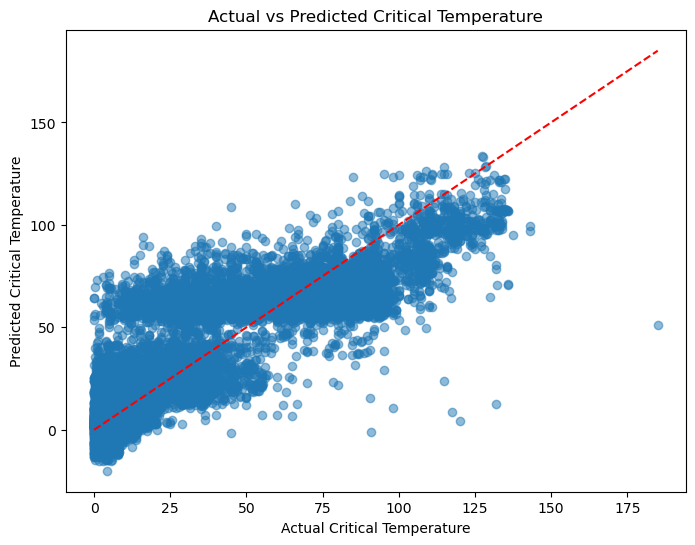

In [29]:
ypred = cross_val_predict(model, X_train_scaled, y_train, cv=cv)

plt.figure(figsize=(8, 6))
plt.scatter(y_train, ypred, alpha=0.5) 
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Line for perfect predictions
plt.xlabel('Actual Critical Temperature')
plt.ylabel('Predicted Critical Temperature')
plt.title('Actual vs Predicted Critical Temperature')
plt.show()

In [30]:
print("Selected features and their importance: \n")

count = 1
count_original = 0
count_engineered = 0
for feature, importance in important_features.items():
    # if the feature was in the original feature set, print "original" next to it
    if feature in X.columns:
        print(f"{count} (original) {feature}: {importance:.4f}")
        count_original += 1
    else:
        print(f"{count} (Engineered) {feature}: {importance:.4f}")
        count_engineered += 1
    count += 1

Selected features and their importance: 

1 (Engineered) wtd_mean_ThermalConductivity range_atomic_radius: 14.2445
2 (Engineered) wtd_std_Valence std_atomic_radius: 9.6252
3 (Engineered) wtd_mean_ThermalConductivity wtd_entropy_ElectronAffinity: 8.8567
4 (Engineered) wtd_mean_ThermalConductivity wtd_std_atomic_mass: 7.6949
5 (Engineered) wtd_mean_ThermalConductivity range_atomic_mass: 6.7002
6 (Engineered) wtd_std_Valence^2: 6.0624
7 (Engineered) std_ElectronAffinity range_atomic_radius: 5.7237
8 (Engineered) wtd_gmean_ThermalConductivity range_atomic_radius: 5.6667
9 (Engineered) wtd_gmean_ThermalConductivity range_atomic_mass: 5.4641
10 (original) wtd_entropy_ThermalConductivity: 5.4480
11 (Engineered) range_atomic_mass wtd_entropy_FusionHeat: 5.4155
12 (Engineered) wtd_entropy_Density^2: 5.1525
13 (Engineered) std_ElectronAffinity wtd_entropy_FusionHeat: 5.1193
14 (original) range_ElectronAffinity: 4.8940
15 (Engineered) range_atomic_radius range_atomic_mass: 4.8738
16 (Engineered) 

In [31]:
print("Number of original features selected:", count_original)
print("Number of engineered features selected:", count_engineered)
print(f"Total features selected: {count_original + count_engineered}")

Number of original features selected: 15
Number of engineered features selected: 34
Total features selected: 49


Overall we ended up with 49 total features which explain 95% of the predictability of the model. Of these features, 15 of them come from the orininal dataset, while the other 34 are engineered polynomial features. When put into a model, this gives the result:

Mean Train $R^2$: $0.7673 \pm 0.0014$

Mean Test $R^2$: $0.7659 \pm 0.0054$

which still falls within the range of the 179 feature model, so no significant data has been lost!